## Bland-Altman analysis to investigate intra-scanner variability of SC

In [18]:
import h5py
import numpy as np
from simulate_sc import (
    simulate_sc_length_bias,
    simulate_sc_density_bias,
    simulate_sc_fns,
    simulate_sc_fps,
)
from ba_plot import ba_plot

atlas_path="/data/wm.connatlas.scale3.h5"

### Simulate SC matrices with a set biases
We will use simulated SC matrices with an artifical set bias in the within-scanner variability to develop a Bland-Altman analysis capable of detecting such biases. 
Once the methodology is refined, we will apply it on the real HCPh data.

In [19]:
SC_matrices = simulate_sc_length_bias()
num_sessions = SC_matrices.shape[0]
atlas_dim = SC_matrices.shape[1]

Using the connectome atlas as reference SC matrix.
Simulated a series of 36 SC matrices of shape (243x243) with higher variability in long connections.


### Prepare an SC matrices array to input into the Bland-Altman analyses

To prepare the SC matrices array to input it in a hierarchical clustering analysis, we will keep only the lower triangle of each SC matrix and unravel it into a row vector.

In [20]:
# Extract the lower triangle of each SC matrix and unravel it into a row vector
SC_matrices_tril = np.array(
    [SC_matrices[i][np.tril_indices(atlas_dim, k=-1)] for i in range(num_sessions)]
)

print(SC_matrices_tril.shape)
# Test whether the shape is as expected
assert SC_matrices_tril.shape == (num_sessions, atlas_dim * (atlas_dim - 1) // 2)

(36, 29403)


## Pre-registered analysis

We compute all pairwise subtractions of sessions (that is rows in SC_matrices) and plot the BA plot for the ten connections with the largest pairwise differences (normalized by the average difference in the pool).


#### Identify the connections corresponding to the 10 largest differences

In [21]:
import pandas as pd

# Convert NaN to zeros to correctly compute differences
SC_matrices_tril[np.isnan(SC_matrices_tril)] = 0

# Compute absolute value of pairwise subtractions for unique pairs (i, j) where i < j
sessions_subtractions = []
session_pairs = []
for i in range(num_sessions):
    for j in range(i + 1, num_sessions):
        subtraction = np.abs(SC_matrices_tril[i] - SC_matrices_tril[j])
        sessions_subtractions.append(subtraction)
        session_pairs.append((i, j))

sessions_subtractions = np.array(sessions_subtractions)
assert sessions_subtractions.shape == (
    num_sessions * (num_sessions - 1) // 2,
    atlas_dim * (atlas_dim - 1) // 2,
)

# Normalize the subtractions by the grand mean value of each connection
grand_mean = np.mean(sessions_subtractions, axis=0)
# Divide by connection grand mean only if it is not zero
non_zero_indices = np.where(grand_mean != 0)[0]
assert grand_mean.shape == (atlas_dim * (atlas_dim - 1) // 2,)
sessions_subtractions[:, non_zero_indices] = (
    sessions_subtractions[:, non_zero_indices] / grand_mean[non_zero_indices]
)
assert sessions_subtractions.shape == (
    num_sessions * (num_sessions - 1) // 2,
    atlas_dim * (atlas_dim - 1) // 2,
)

# Identify the 10 maximum element-wise subtractions in sessions_subtractions
max_indices = np.unravel_index(
    np.argsort(sessions_subtractions, axis=None)[-10:], sessions_subtractions.shape
)
max_values = sessions_subtractions[max_indices]
# Verify that we indeed extract the 10 maximum differences
assert np.min(max_values) > np.max(
    np.ma.masked_array(
        sessions_subtractions, mask=np.isin(sessions_subtractions, max_values)
    )
)

print(
    f"The 10 biggest differences in a structural connection value between two sessions are: {max_values}"
)
# Extract the session pairs corresponding to the 10 biggest differences
max_session_pairs = [session_pairs[idx] for idx in max_indices[0]]

print(
    f"The session pairs corresponding to the 10 biggest differences are: {max_session_pairs}"
)
print(
    f"The connection corresponding to the 10 biggest differences are {max_indices[1]}"
)  # TO DO: match connections indices to the brain regions

The 10 biggest differences in a structural connection value between two sessions are: [5.92075957 5.92148356 5.94865318 5.96796969 6.03117838 6.03570755
 6.09997175 6.11147117 6.13901225 6.23956818]
The session pairs corresponding to the 10 biggest differences are: [(18, 29), (7, 35), (2, 23), (7, 22), (1, 9), (10, 23), (7, 19), (34, 35), (1, 11), (12, 17)]
The connection corresponding to the 10 biggest differences are [20596  5415 26384 25410 23733 13176  3328  5415 23733    94]


#### Plot the BA plot of the connections with the biggest differences

(630,)


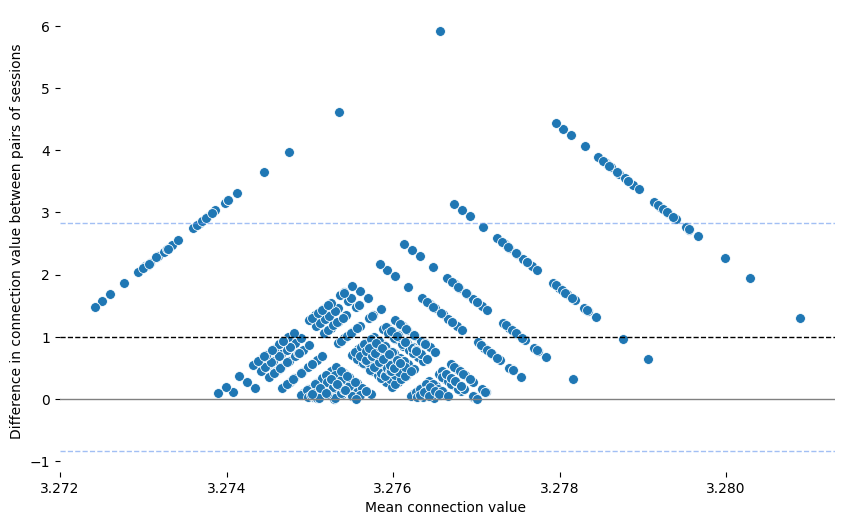

(630,)


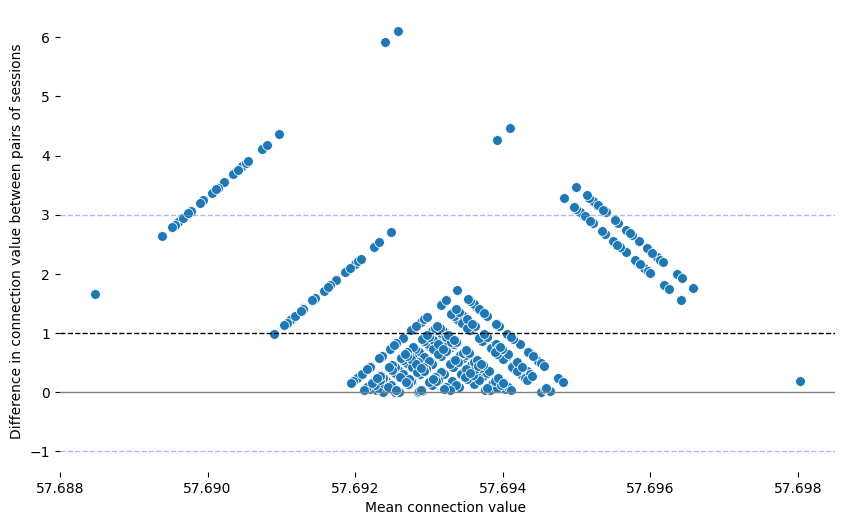

(630,)


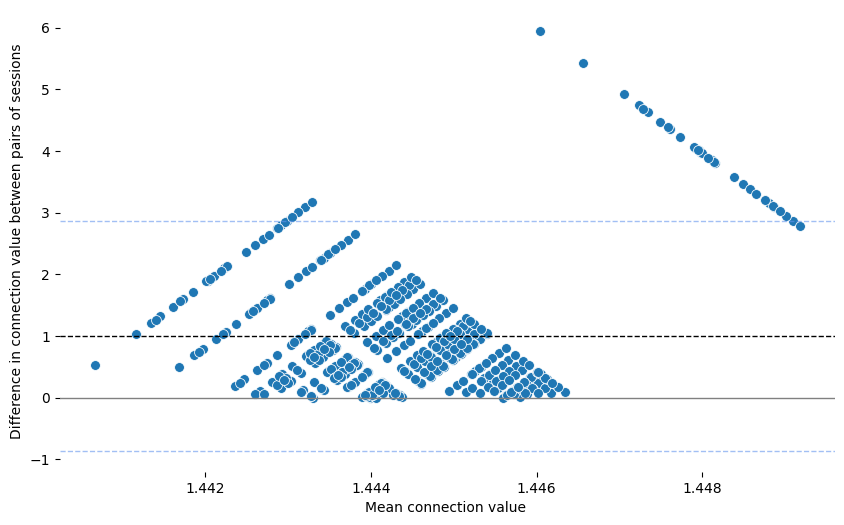

(630,)


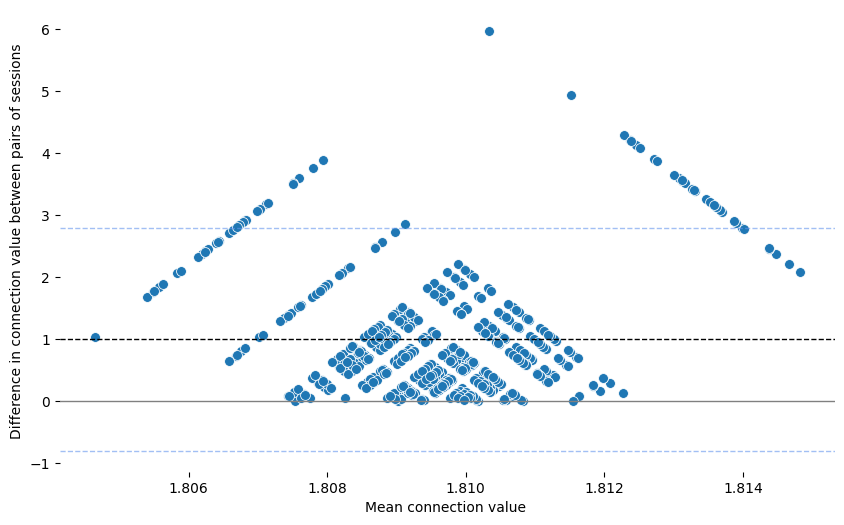

(630,)


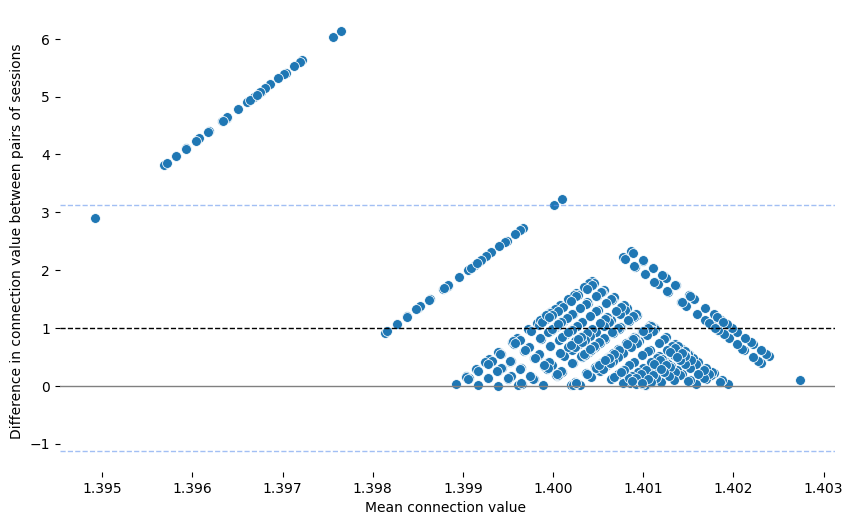

(630,)


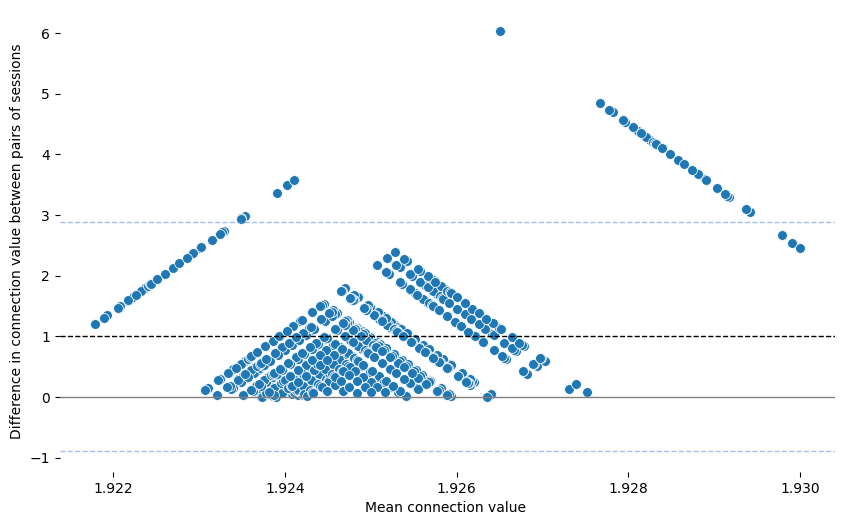

(630,)


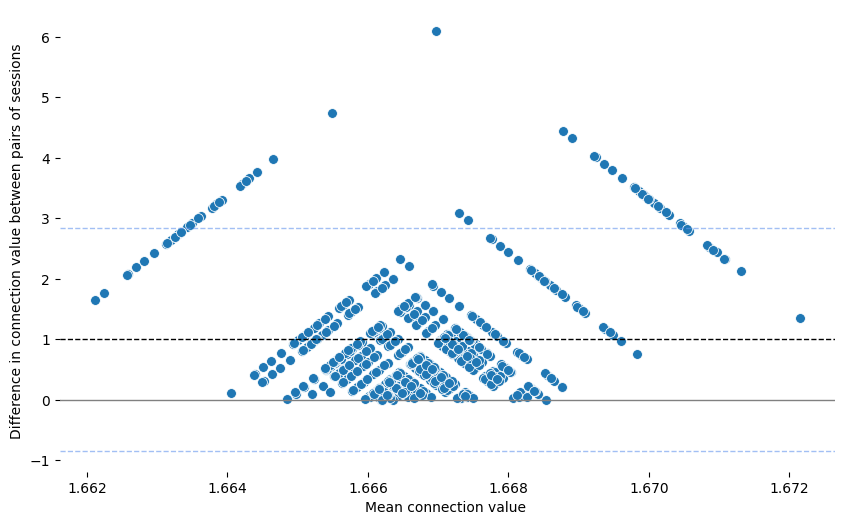

(630,)


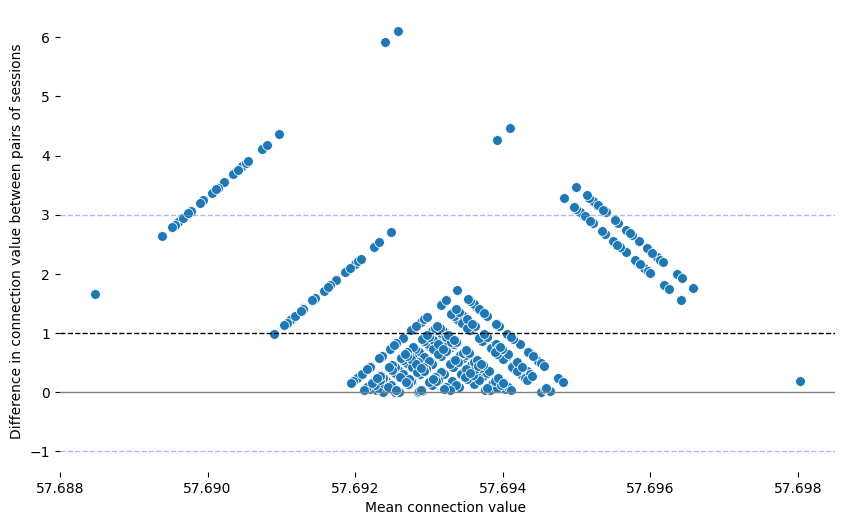

(630,)


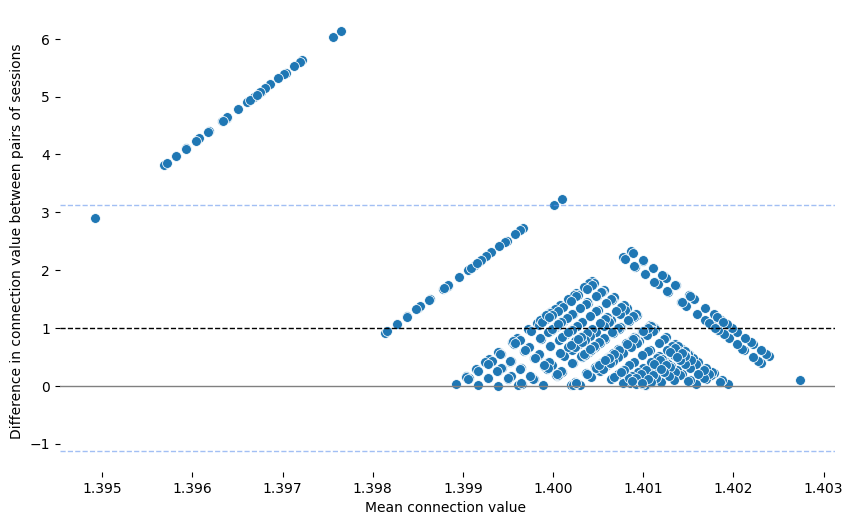

(630,)


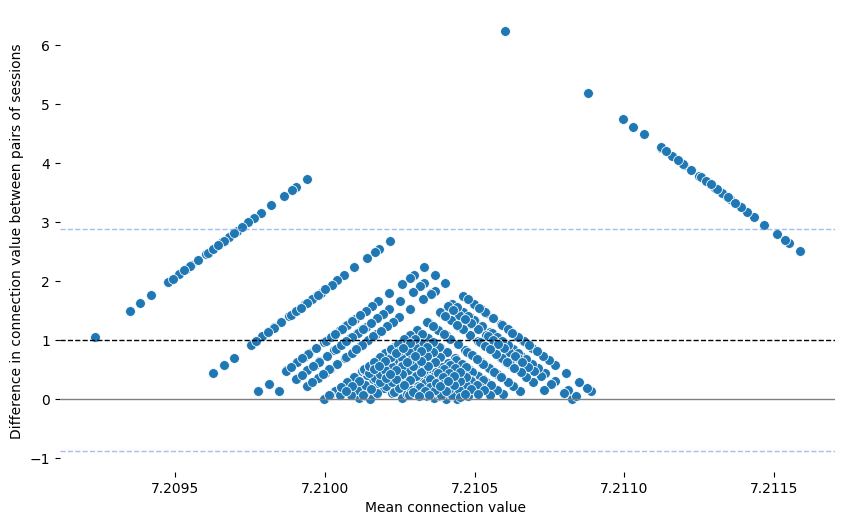

In [22]:
for conn in max_indices[1]:
    # Extract the vector of differences and means
    conn_diff = sessions_subtractions[:, conn]
    SC_value = SC_matrices_tril[:, conn]
    conn_mean = np.array([
        np.mean([SC_matrices_tril[i, conn], SC_matrices_tril[j, conn]])
        for i in range(num_sessions) 
        for j in range(i + 1, num_sessions)
    ])
    print(conn_diff.shape)
    assert conn_mean.shape == (num_sessions * (num_sessions - 1) // 2,)
    assert conn_diff.shape == conn_mean.shape, f"The mean vector has a shape of {conn_mean.shape} while the difference vector has a shape of {conn_diff.shape}."

    # Plot the corresponding BA plot
    ba_plot(
        conn_diff,
        conn_mean,
    )

## BA plot with all connections, all pair-wise session comparisons

In [23]:
with h5py.File(atlas_path, "r") as f:
        length_matrix = np.array(f["matrices"]["length"])

length_tril = length_matrix[np.tril_indices(atlas_dim, k=-1)]


print(length_tril.shape)


(29403,)


In [24]:
# Compute all pairwise mean for unique pairs (i, j) where i < j
sessions_means = []
for i in range(num_sessions):
    for j in range(i + 1, num_sessions):
        means = np.mean(np.vstack((SC_matrices_tril[i], SC_matrices_tril[j])), axis=0)
        sessions_means.append(means)

sessions_means = np.array(sessions_means)
sessions_means.shape

(630, 29403)

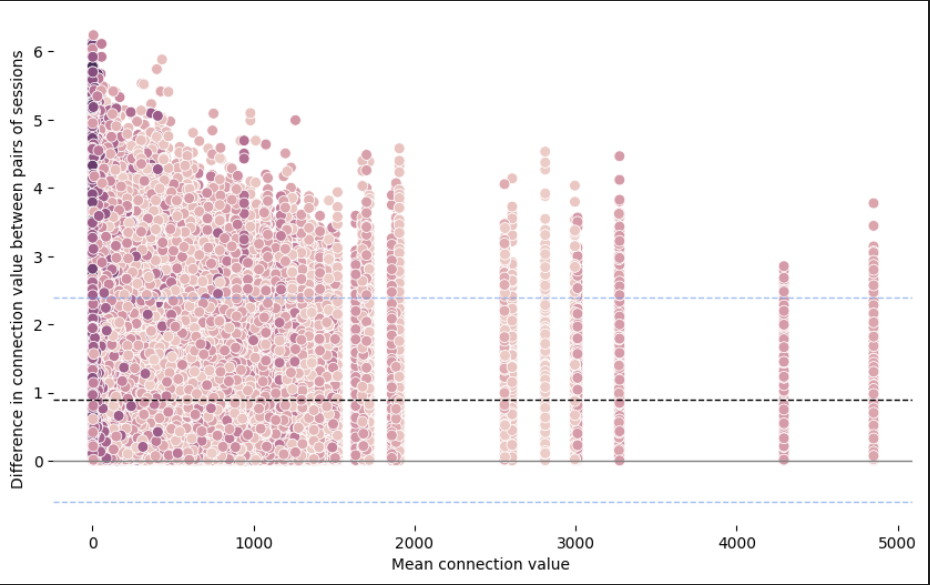

In [36]:
from IPython.display import Image, display

# # Compute all pairwise mean for unique pairs (i, j) where i < j
# sessions_means = []
# for i in range(num_sessions):
#     for j in range(i + 1, num_sessions):
#         means = np.mean(np.vstack((SC_matrices_tril[i], SC_matrices_tril[j])), axis=0)
#         sessions_means.append(means)

# sessions_means = np.array(sessions_means)
# sessions_means.shape

# length_hue = np.tile(length_tril, num_sessions * (num_sessions - 1) // 2)
# np.testing.assert_array_equal(length_hue[:len(length_tril)], length_tril)

# ba_plot(
#     sessions_subtractions.flatten(),
#     sessions_means.flatten(), 
#     hue = length_hue,
# )
# Display the photo
image_path = "/home/cprovins/Documents/HCPh_analysis/BAplot_allconnections_lengthhue.png"
display(Image(filename=image_path))
